# Comparison of Global Context Correlations: 50 Units vs. 100 Units

This notebook performs a systematic comparison between the correlations calculated for **50 Units** and **100 Units** in the Global Context across different  OpenAlex Topics.



In [1]:
#Montar mi google drive para poder usar los archivos
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'figure.titlesize': 14,
    'figure.titleweight': 'bold'
})


# Initialize HTML report container
text = """
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Comparison Analysis Report</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; color: #2c3e50; }
        h1, h2, h3 { color: #2c3e50; }
        table { border-collapse: collapse; width: 100%; margin-bottom: 20px; }
        th, td { border: 1px solid #bdc3c7; padding: 8px; text-align: left; }
        th { background-color: #f4f6f7; font-weight: bold; }
        img { max-width: 100%; height: auto; display: block; margin: 20px 0; }
    </style>
</head>
<body>
<h1>Comparison Analysis Report (50 vs. 100 Units)</h1>
"""


In [14]:
# Define paths to the CSV files
paths = {
    '50_pearson': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments - subir/Citable_Documents/OpenAlex/GlobalContext - 50/pearson_correlation_AI_FMeasure.csv',
    '50_spearman': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments - subir/Citable_Documents/OpenAlex/GlobalContext - 50/Spearman_correlation_AI_FMeasure.csv',
    '100_pearson': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments - subir/Citable_Documents/OpenAlex/GlobalContext - 100/pearson_correlation_AI_FMeasure.csv',
    '100_spearman': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments - subir/Citable_Documents/OpenAlex/GlobalContext - 100/Spearman_correlation_AI_FMeasure.csv'
}

# Load files
dfs = {}
for name, path in paths.items():
    if not os.path.exists(path):
        # Try relative paths as f50back
        if '2026' in path:
            rel_path = f'Global Context/{os.path.basename(path)}'
        else:
            rel_path = f'../../ManuscriptExperiments/Global Context/{os.path.basename(path)}'
        if os.path.exists(rel_path):
            path = rel_path

    dfs[name] = pd.read_csv(path, index_col=0)
    print(f"Successfully loaded {name} (Shape: {dfs[name].shape})")


Successfully loaded 50_pearson (Shape: (26, 11))
Successfully loaded 50_spearman (Shape: (26, 11))
Successfully loaded 100_pearson (Shape: (26, 11))
Successfully loaded 100_spearman (Shape: (26, 11))


In [5]:
def get_comparison_table(col_name):
    """
    Creates a side-by-side comparison table for a specific correlation column.
    """
    # Base index of OpenAlex Fields from the Pearson 50 dataset
    index_ref = dfs['50_pearson'].index

    df_comp = pd.DataFrame(index=index_ref)

    # Pearson
    df_comp['Pearson (50)'] = dfs['50_pearson'][col_name]
    df_comp['Pearson (100)'] = dfs['100_pearson'][col_name]
    df_comp['Pearson Diff (100 - 50)'] = df_comp['Pearson (100)'] - df_comp['Pearson (50)']

    # Spearman (aligning indices)
    df_comp['Spearman (50)'] = df_comp.index.map(dfs['50_spearman'][col_name])
    df_comp['Spearman (100)'] = df_comp.index.map(dfs['100_spearman'][col_name])
    df_comp['Spearman Diff (100 - 50)'] = df_comp['Spearman (100)'] - df_comp['Spearman (50)']

    # Sort OpenAlex Fields alphabetic50y
    df_comp = df_comp.sort_index()
    return df_comp

def display_styled_table(df, title):
    """
    Applies advanced pandas styler to color-code difference columns and display.
    """
    styled = df.style.format("{:.4f}")\
        .background_gradient(cmap="coolwarm", subset=["Pearson Diff (100 - 50)", "Spearman Diff (100 - 50)"], vmin=-0.2, vmax=0.2)\
        .set_caption(f"<b style='font-size: 14px;'>{title}</b>")\
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#f4f6f7'), ('color', '#2c3e50'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'right')]},
            {'selector': 'caption', 'props': [('margin-bottom', '10px'), ('color', '#2c3e50')]}
        ])
    display(styled)
    global text
    text = text + f"<h2>{title}</h2>" + styled.to_html() + "<br><br>"

def plot_comparison(df, user_name):
    """
    Generates side-by-side horizontal bar plots to visualize the differences in correlations.
    """
    # Prepare Pearson data for Seaborn
    df_pearson = pd.DataFrame({
        'OpenAlex Field': df.index,
        '50 Units': df['Pearson (50)'].values,
        '100 Units': df['Pearson (100)'].values
    }).melt(id_vars='OpenAlex Field', var_name='Dataset', value_name='Pearson Correlation')

    # Prepare Spearman data for Seaborn
    df_spearman = pd.DataFrame({
        'OpenAlex Field': df.index,
        '50 Units': df['Spearman (50)'].values,
        '100 Units': df['Spearman (100)'].values
    }).melt(id_vars='OpenAlex Field', var_name='Dataset', value_name='Spearman Correlation')

    fig, axes = plt.subplots(1, 2, figsize=(16, 9), sharey=True)

    # Harmonious colors: Cool Blue for 50, Warm Coral for 100
    colors = {'50 Units': '#2b7bba', '100 Units': '#e76f51'}

    # Pearson Subplot
    sns.barplot(
        data=df_pearson,
        y='OpenAlex Field',
        x='Pearson Correlation',
        hue='Dataset',
        palette=colors,
        ax=axes[0]
    )
    axes[0].set_title("Pearson Correlation Coefficient", fontsize=13, pad=10)
    axes[0].set_xlabel("Correlation Value")
    axes[0].set_ylabel("OpenAlex Field")
    axes[0].set_xlim(-1.05, 1.05)
    axes[0].grid(True, linestyle="--", alpha=0.6, axis='x')
    axes[0].legend().set_visible(False)

    # Spearman Subplot
    sns.barplot(
        data=df_spearman,
        y='OpenAlex Field',
        x='Spearman Correlation',
        hue='Dataset',
        palette=colors,
        ax=axes[1]
    )
    axes[1].set_title("Spearman Correlation Coefficient", fontsize=13, pad=10)
    axes[1].set_xlabel("Correlation Value")
    axes[1].set_ylabel("")
    axes[1].set_xlim(-1.05, 1.05)
    axes[1].grid(True, linestyle="--", alpha=0.6, axis='x')
    axes[1].legend().set_visible(False)

    # Add single common legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=2, fontsize=11)

    plt.suptitle(f"Correlation Comparison: {user_name} (50 vs. 100)", fontsize=15, y=1.03)
    plt.tight_layout()
    import os
    os.makedirs('figuras', exist_ok=True)
    fig_name_clean = user_name.replace(' ', '_').replace('/', '_').replace(':', '_').replace('(', '').replace(')', '')
    fig_filename = f"figuras/comparison_{fig_name_clean}.png"
    plt.savefig(fig_filename, bbox_inches='tight')
    global text
    text = text + f"<img src='{fig_filename}' alt='{user_name} Comparison'><br><br>\n"
    plt.show()


## 1. AI vs DShareC Correlation Comparison

This section compares the Pearson and Spearman correlations of **Activity Index (AI)** versus **DShareC**.
This indicator measures how the proportion of publications (AI) relates to the document share in the citation distribution.


,Pearson (50),Pearson (100),Pearson Diff (100 - 50),Spearman (50),Spearman (100),Spearman Diff (100 - 50)
Agricultural and Biological Sciences,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Arts and Humanities,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
"Biochemistry, Genetics and Molecular Biology",1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
"Business, Management and Accounting",1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Chemical Engineering,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
Chemistry,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
Computer Science,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Decision Sciences,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Dentistry,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
Earth and Planetary Sciences,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000


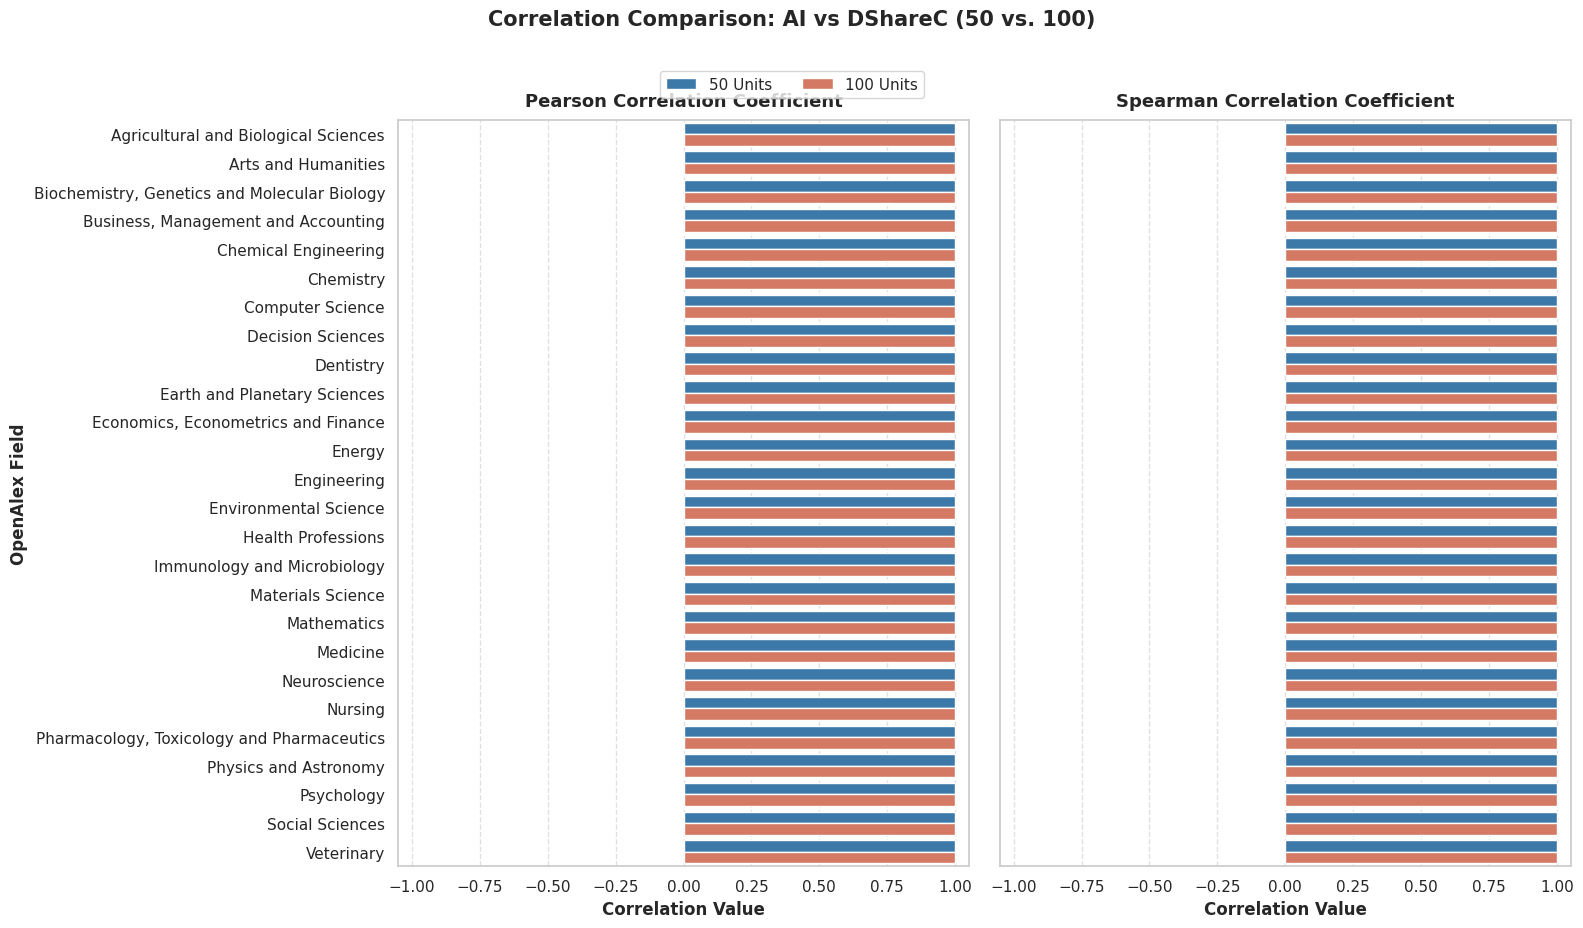

In [6]:
df_ai_dsharec = get_comparison_table('AI vs DShareC')
display_styled_table(df_ai_dsharec, 'Table 1: AI vs DShareC (50 vs. 100)')
plot_comparison(df_ai_dsharec, 'AI vs DShareC')


## 2. AI vs CShareD Correlation Comparison

This section compares the correlations of **Activity Index (AI)** versus **CShareD**.


,Pearson (50),Pearson (100),Pearson Diff (100 - 50),Spearman (50),Spearman (100),Spearman Diff (100 - 50)
Neuroscience,0.3591,0.3195,-0.0396,0.6471,0.6200,-0.0272
Chemical Engineering,0.3675,0.4290,0.0615,0.5801,0.5251,-0.0550
"Biochemistry, Genetics and Molecular Biology",0.3232,0.3313,0.0081,0.5242,0.5138,-0.0105
Physics and Astronomy,0.1636,0.1955,0.0319,0.5219,0.5724,0.0504
Materials Science,0.3037,0.3656,0.0618,0.5138,0.5279,0.0140
Veterinary,0.1551,0.1606,0.0055,0.4960,0.4512,-0.0448
Earth and Planetary Sciences,0.2416,0.3367,0.0951,0.4833,0.5090,0.0256
Chemistry,0.2972,0.3493,0.0521,0.4409,0.5403,0.0994
Engineering,0.3178,0.4033,0.0855,0.4366,0.3783,-0.0583
Dentistry,0.2354,0.3927,0.1573,0.3809,0.4750,0.0941


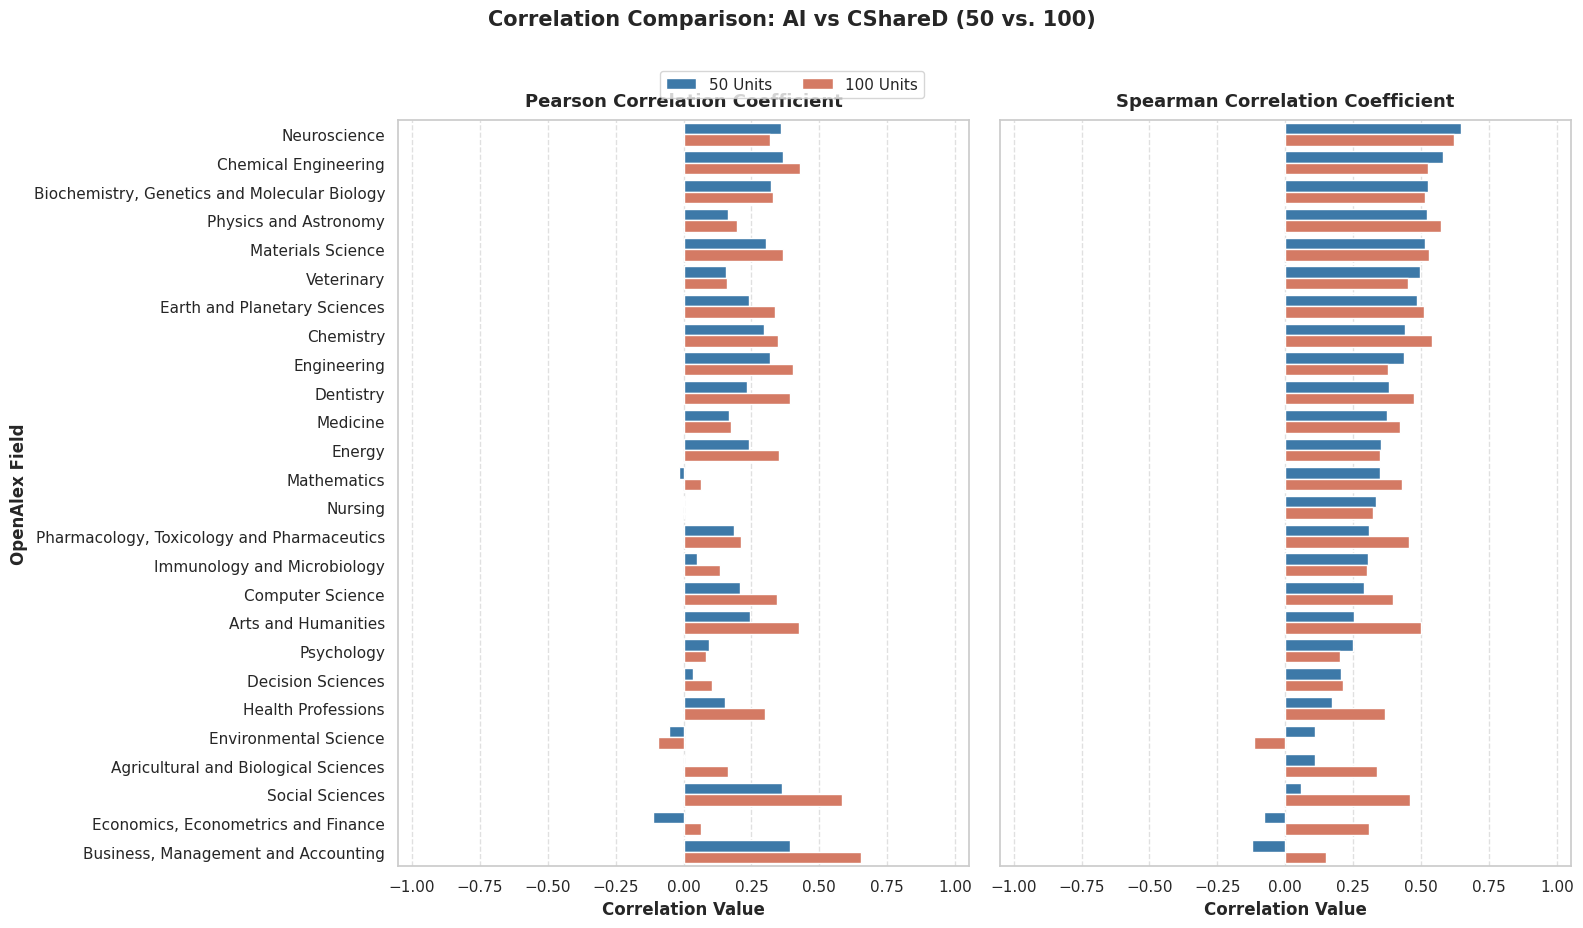

In [7]:
df_ai_cshared = get_comparison_table('AI vs CShareD')
display_styled_table(df_ai_cshared.sort_values('Spearman (50)', ascending=False), 'Table 2: AI vs CShareD (50 vs. 100)')
plot_comparison(df_ai_cshared.sort_values('Spearman (50)', ascending=False), 'AI vs CShareD')


In [8]:
df_ai_cshared.corr(method='spearman')

,Pearson (50),Pearson (100),Pearson Diff (100 - 50),Spearman (50),Spearman (100),Spearman Diff (100 - 50)
Pearson (50),1.000000,0.908376,0.171282,0.407179,0.554872,0.021538
Pearson (100),0.908376,1.000000,0.496752,0.201368,0.459145,0.255385
Pearson Diff (100 - 50),0.171282,0.496752,1.000000,-0.513846,-0.135043,0.752479
Spearman (50),0.407179,0.201368,-0.513846,1.000000,0.772308,-0.528889
Spearman (100),0.554872,0.459145,-0.135043,0.772308,1.000000,0.035214
Spearman Diff (100 - 50),0.021538,0.255385,0.752479,-0.528889,0.035214,1.000000


## 3. F-Measure vs DShareC (ShareC) Correlation Comparison

This section compares the correlations of **F-Measure** versus **DShareC**.


,Pearson (50),Pearson (100),Pearson Diff (100 - 50),Spearman (50),Spearman (100),Spearman Diff (100 - 50)
Veterinary,0.8091,0.9785,0.1694,0.8671,0.9769,0.1097
Chemical Engineering,0.7710,0.9304,0.1593,0.7552,0.9065,0.1512
Neuroscience,0.6768,0.7060,0.0291,0.6996,0.7590,0.0595
Dentistry,0.6188,0.9399,0.3211,0.5967,0.8874,0.2907
Physics and Astronomy,0.4061,0.6148,0.2086,0.5864,0.6879,0.1015
Materials Science,0.5118,0.6358,0.1239,0.5540,0.6605,0.1065
Earth and Planetary Sciences,0.4419,0.6426,0.2007,0.5531,0.7155,0.1624
Nursing,0.5763,0.8244,0.2481,0.5505,0.7621,0.2117
"Biochemistry, Genetics and Molecular Biology",0.4533,0.4530,-0.0003,0.5446,0.5794,0.0348
"Pharmacology, Toxicology and Pharmaceutics",0.6807,0.9271,0.2465,0.5195,0.8605,0.3410


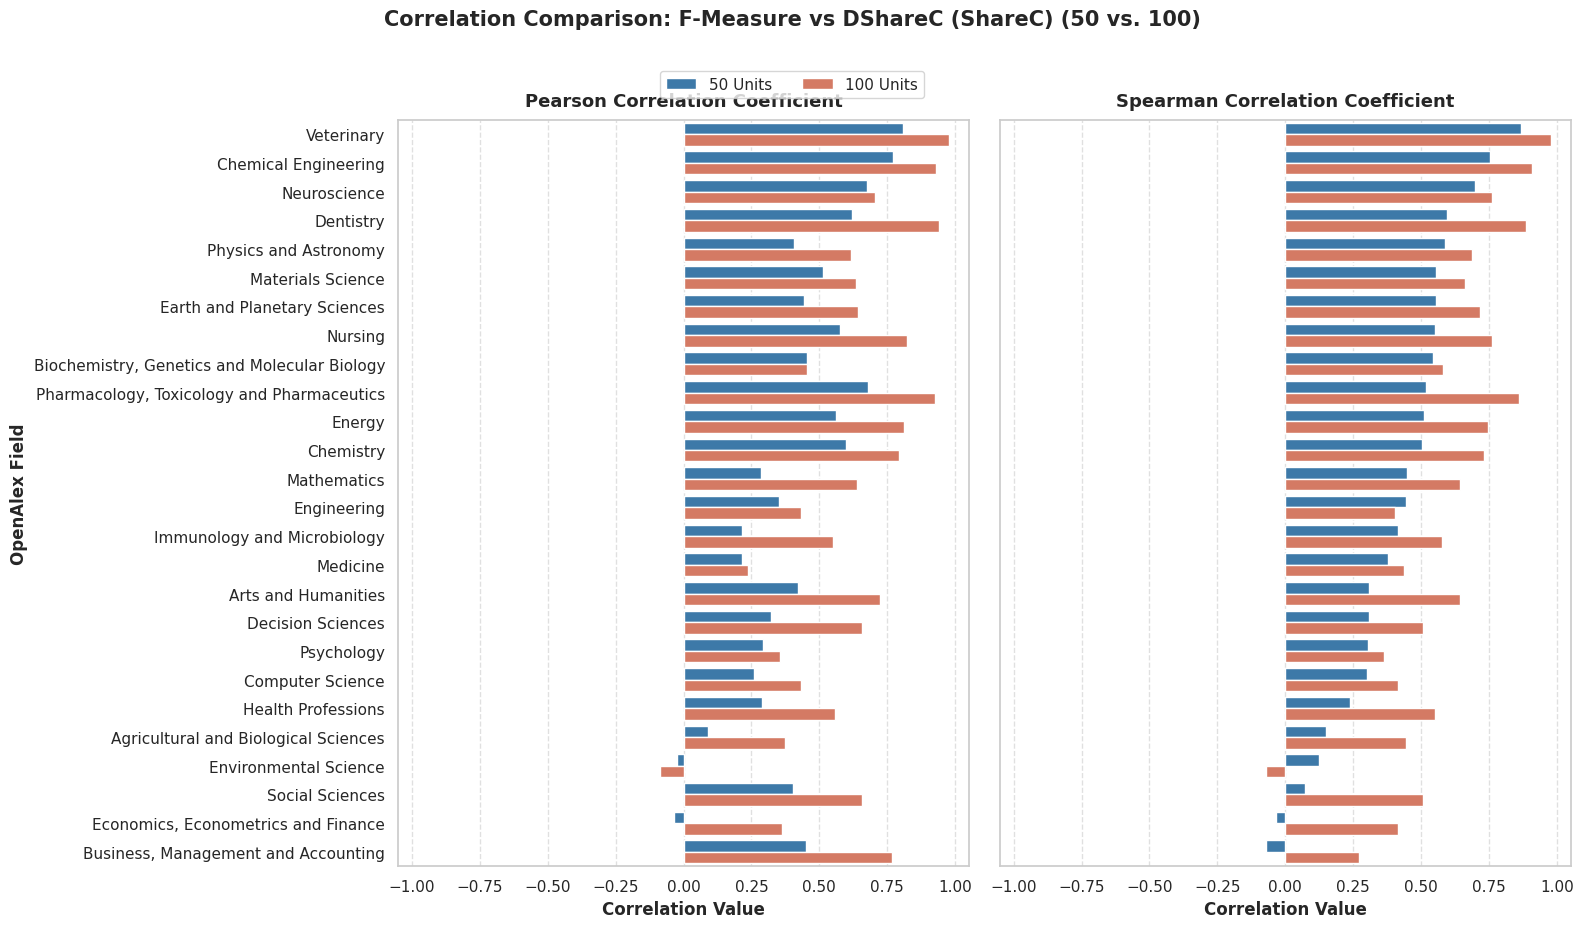

In [9]:
df_f_dsharec = get_comparison_table('F-Measure vs DShareC')
display_styled_table(df_f_dsharec.sort_values('Spearman (50)', ascending=False), 'Table 3: F-Measure vs DShareC (50 vs. 100)')
plot_comparison(df_f_dsharec.sort_values('Spearman (50)', ascending=False), 'F-Measure vs DShareC (ShareC)')



In [10]:
df_f_dsharec.corr(method='spearman')

,Pearson (50),Pearson (100),Pearson Diff (100 - 50),Spearman (50),Spearman (100),Spearman Diff (100 - 50)
Pearson (50),1.000000,0.872137,-0.195897,0.760000,0.819425,0.055043
Pearson (100),0.872137,1.000000,0.244444,0.572650,0.811902,0.401026
Pearson Diff (100 - 50),-0.195897,0.244444,1.000000,-0.311453,0.023940,0.785299
Spearman (50),0.760000,0.572650,-0.311453,1.000000,0.861149,-0.341538
Spearman (100),0.819425,0.811902,0.023940,0.861149,1.000000,0.131669
Spearman Diff (100 - 50),0.055043,0.401026,0.785299,-0.341538,0.131669,1.000000


## 4. F-Measure vs CShareD Correlation Comparison

This section compares the correlations of **F-Measure** versus **CShareD**.


,Pearson (50),Pearson (100),Pearson Diff (100 - 50),Spearman (50),Spearman (100),Spearman Diff (100 - 50)
Medicine,0.9826,0.9852,0.0025,0.9999,0.9990,-0.0008
Computer Science,0.9452,0.9500,0.0048,0.9997,0.9988,-0.0009
Engineering,0.9862,0.9901,0.0039,0.9995,0.9978,-0.0018
Social Sciences,0.9867,0.9860,-0.0007,0.9995,0.9964,-0.0030
Environmental Science,0.8919,0.9134,0.0215,0.9995,0.9967,-0.0027
"Biochemistry, Genetics and Molecular Biology",0.9040,0.9231,0.0191,0.9983,0.9868,-0.0115
Agricultural and Biological Sciences,0.9034,0.8982,-0.0052,0.9980,0.9885,-0.0096
"Economics, Econometrics and Finance",0.8394,0.8359,-0.0035,0.9977,0.9901,-0.0076
"Business, Management and Accounting",0.9622,0.9633,0.0011,0.9967,0.9864,-0.0103
Psychology,0.8297,0.8278,-0.0019,0.9966,0.9754,-0.0211


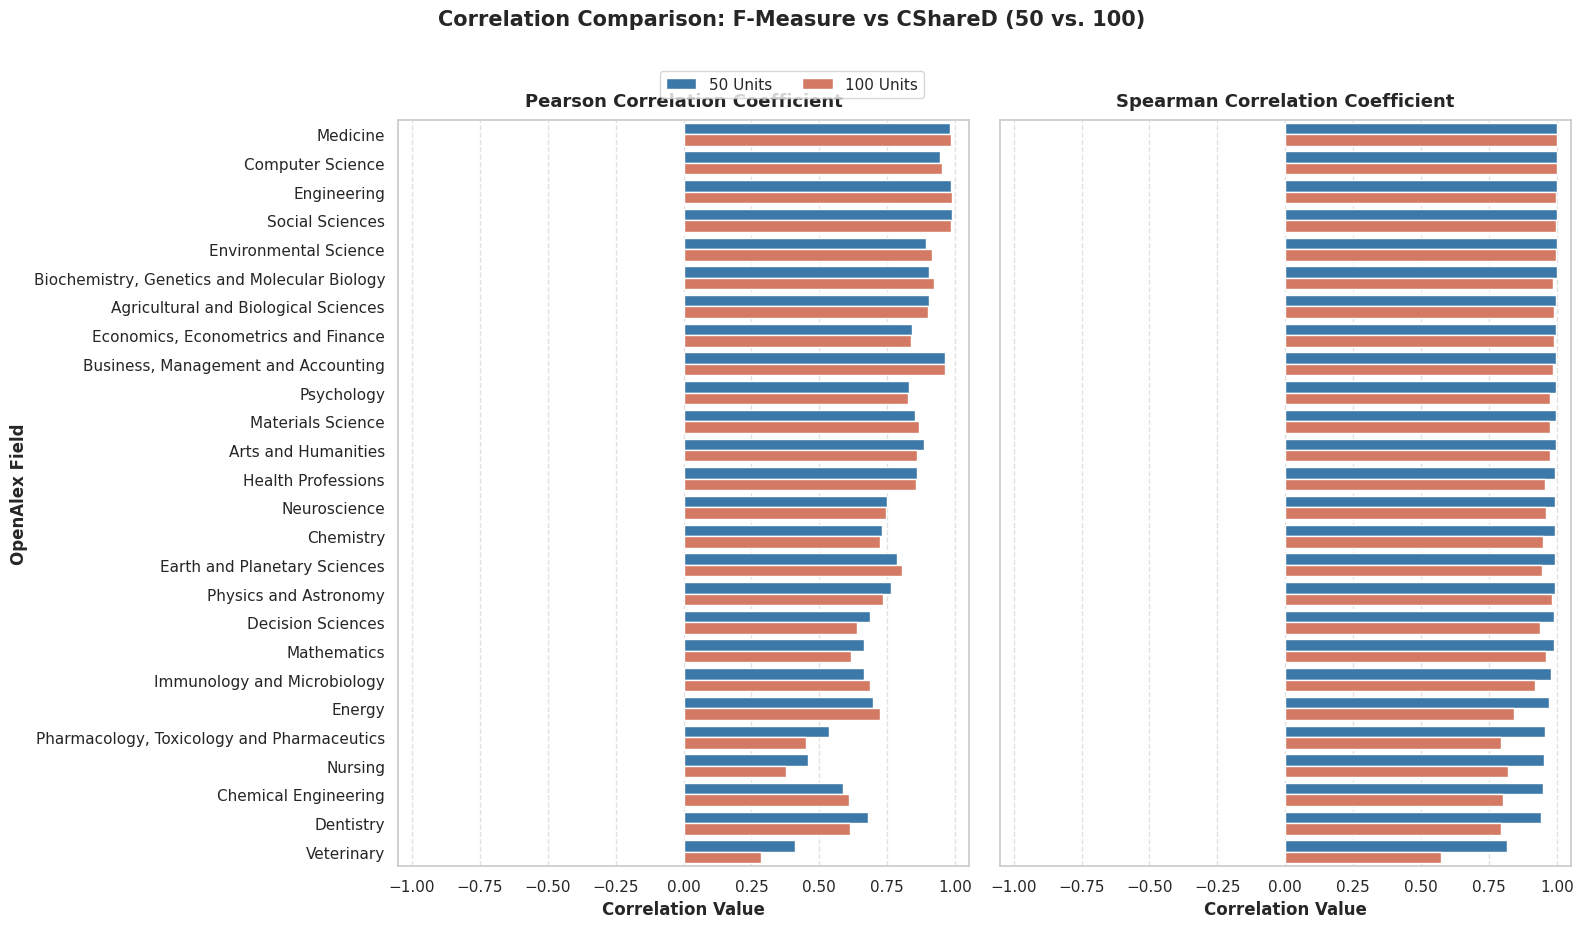

In [11]:
df_f_cshared = get_comparison_table('F-Measure vs CShareD')
display_styled_table(df_f_cshared.sort_values('Spearman (50)', ascending=False), 'Table 4: F-Measure vs CShareD (50 vs. 100)')
plot_comparison(df_f_cshared.sort_values('Spearman (50)', ascending=False), 'F-Measure vs CShareD')


## 5. Summary Statistics and Over50 Analysis (Absolute Discrepancies)

To synthesize the comparison, let's look at the summary statistics of the **absolute differences** across 50 22 OpenAlex Fields for each of the four indicator pairs.

Using absolute values is essential because it measures the magnitude of the discrepancy (change) regardless of whether the correlation went up or down. For example, a large negative change like -0.76708 represents a major discrepancy of 0.76708 in absolute terms. Computing statistics on signed differences can cause positive and negative changes to cancel each other out, hiding the true extent of the changes.


In [12]:
summary_data = []
pairs_mapping = {
    'AI vs DShareC': 'AI vs DShareC',
    'AI vs CShareD': 'AI vs CShareD',
    'F-Measure vs DShareC': 'F-Measure vs DShareC',
    'F-Measure vs CShareD': 'F-Measure vs CShareD'
}

for user_name, csv_name in pairs_mapping.items():
    df_p = get_comparison_table(csv_name)
    pearson_abs = df_p['Pearson Diff (100 - 50)'].abs()
    spearman_abs = df_p['Spearman Diff (100 - 50)'].abs()
    summary_data.append({
        'Indicator Pair': user_name,
        'Mean Abs Pearson Diff': pearson_abs.mean(),
        'Median Abs Pearson Diff': pearson_abs.median(),
        'Max Abs Pearson Diff': pearson_abs.max(),
        'Min Abs Pearson Diff': pearson_abs.min(),
        'Mean Abs Spearman Diff': spearman_abs.mean(),
        'Median Abs Spearman Diff': spearman_abs.median(),
        'Max Abs Spearman Diff': spearman_abs.max(),
        'Min Abs Spearman Diff': spearman_abs.min()
    })

df_summary = pd.DataFrame(summary_data).set_index('Indicator Pair')

styled_summary = df_summary.style.format("{:.5f}")\
    .background_gradient(cmap="Reds", vmin=0.0, vmax=0.3)\
    .set_caption("<b style='font-size: 14px;'>Over50 Comparison Summary: Absolute Discrepancies (|100 - 50|)</b>")\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'right')]},
        {'selector': 'caption', 'props': [('margin-bottom', '10px'), ('color', '#2c3e50')]}
    ])
display(styled_summary)
global text
text = text + "<h2>Over50 Comparison Summary</h2>" + styled_summary.to_html() + "<br><br>"


,Mean Abs Pearson Diff,Median Abs Pearson Diff,Max Abs Pearson Diff,Min Abs Pearson Diff,Mean Abs Spearman Diff,Median Abs Spearman Diff,Max Abs Spearman Diff,Min Abs Spearman Diff
Indicator Pair,,,,,,,,
AI vs DShareC,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
AI vs CShareD,0.08938,0.07466,0.26223,0.00355,0.11147,0.05661,0.40120,0.00448
F-Measure vs DShareC,0.20758,0.22755,0.39600,0.00029,0.20087,0.19716,0.44869,0.03477
F-Measure vs CShareD,0.02699,0.01893,0.12446,0.00071,0.05324,0.02663,0.24016,0.00083


In [13]:
global text
text = text + "</body></html>"
with open("50_vs_100 Units.html", "w", encoding="utf-8") as f:
    f.write(text)
print("Saved report to 50_vs_100 Units.html")


Saved report to 50_vs_100 Units.html
